# 04 · Model Evaluation

Loads saved model and scores, applies isotonic calibration, plots ROC/PR/calibration curves,
Precision@K, cost analysis, SHAP beeswarm/waterfall, and weekly time-period drift analysis.

**Prerequisite:** run notebook `03` first (or the pipeline `train` stage).

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import gc, json, pickle

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, confusion_matrix,
    classification_report, brier_score_loss)
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression

%matplotlib inline
plt.rcParams.update({
    "figure.facecolor":"#0F1117","axes.facecolor":"#1A1D27","axes.edgecolor":"#2E3347",
    "text.color":"#E0E0E0","axes.labelcolor":"#E0E0E0","xtick.color":"#9AA0B0",
    "ytick.color":"#9AA0B0","grid.color":"#2E3347","grid.linestyle":"--",
    "font.family":"monospace","figure.dpi":120,
})
PAL = {"lgb":"#A259FF","fraud":"#E84545","normal":"#4CAF50","accent":"#F5A623","blue":"#4A90D9"}
COST_FN = 150.0   # missed fraud cost
COST_FP =   5.0   # false alarm cost
print("Imports OK")


Imports OK


In [2]:
from pathlib import Path
# ── Change this to point to your repo root if running from elsewhere
REPO_ROOT = Path(".").resolve().parent  # assumes notebook is in notebooks/
DATA_DIR  = REPO_ROOT / "data" / "raw"
PROC_DIR  = REPO_ROOT / "data" / "processed"
MODEL_DIR = REPO_ROOT / "models"
OUT_DIR   = REPO_ROOT / "outputs"
for d in [PROC_DIR, MODEL_DIR, OUT_DIR]: d.mkdir(parents=True, exist_ok=True)
print(f"Data  : {DATA_DIR}")
print(f"Proc  : {PROC_DIR}")

Data  : /Users/MYOUSSF/Desktop/Projects/fraud_detection_project/data/raw
Proc  : /Users/MYOUSSF/Desktop/Projects/fraud_detection_project/data/processed


In [3]:
# ── Load artefacts ────────────────────────────────────────────────────────────
with open(MODEL_DIR/"lgb_model.pkl","rb") as fh: model = pickle.load(fh)
with open(PROC_DIR/"feature_meta.json") as fh: feat_meta = json.load(fh)
with open(PROC_DIR/"graph_meta.json")   as fh: graph_meta = json.load(fh)

feature_names = feat_meta["features"] + graph_meta["graph_features"]
raw_scores    = np.load(PROC_DIR/"lgb_scores_test.npy")
shap_values   = np.load(PROC_DIR/"shap_values.npy")
shap_idx      = np.load(PROC_DIR/"shap_sample_idx.npy")
shap_names    = list(np.load(PROC_DIR/"shap_feature_names.npy", allow_pickle=True))

# Labels and timestamps
y_test   = np.load(PROC_DIR/"y_graph_test.npy")
g_tx_te  = np.load(PROC_DIR/"graph_tx_ids_test.npy")
tx_ids_test = np.load(PROC_DIR/"tx_ids_test_tab.npy")
tx_dt_full  = np.load(PROC_DIR/"tx_dt_test.npy")
dt_lookup   = {int(tid): dt for tid,dt in zip(tx_ids_test, tx_dt_full)}
tx_dt_test  = np.array([dt_lookup.get(int(t),0.0) for t in g_tx_te])

# Feature matrix for calibration and SHAP
N_TAB = len(feat_meta["features"]); N_GPH = len(graph_meta["graph_features"])
X_tab = np.load(PROC_DIR/"X_test_tab.npy")
G_te  = np.load(PROC_DIR/"graph_features_test.npy")
tx_tab = np.load(PROC_DIR/"tx_ids_test_tab.npy")
lkup  = {int(tid): i for i, tid in enumerate(tx_tab)}
block = np.zeros((len(G_te), N_TAB), dtype=np.float32)
for i, tid in enumerate(g_tx_te):
    idx = lkup.get(int(tid))
    if idx is not None: block[i] = X_tab[idx]
X_test = np.hstack([block, G_te]); del block, G_te, X_tab; gc.collect()

print(f"y_test  : {y_test.shape}  fraud={y_test.sum():,} ({y_test.mean()*100:.2f}%)")
print(f"Scores  : min={raw_scores.min():.4f}  max={raw_scores.max():.4f}")
print(f"X_test  : {X_test.shape}")


y_test  : (118108,)  fraud=4,133 (3.50%)
Scores  : min=0.0001  max=0.9993
X_test  : (118108, 39)


## 1 · Core metrics

In [4]:
auroc = roc_auc_score(y_test, raw_scores)
auprc = average_precision_score(y_test, raw_scores)

prec, rec, pr_thr = precision_recall_curve(y_test, raw_scores)
f1s    = 2*prec*rec/(prec+rec+1e-9)
thr_f1 = float(pr_thr[np.argmax(f1s[:-1])])

thr_range = np.linspace(0.01, 0.99, 200)
costs = []
for thr in thr_range:
    yp = (raw_scores >= thr).astype(int)
    tn_,fp_,fn_,tp_ = confusion_matrix(y_test, yp, labels=[0,1]).ravel()
    costs.append(fn_*COST_FN + fp_*COST_FP)
thr_cost = float(thr_range[int(np.argmin(costs))])

y_pred = (raw_scores >= thr_f1).astype(int)
cm = confusion_matrix(y_test, y_pred)

print(f"AUROC          : {auroc:.4f}")
print(f"AUPRC          : {auprc:.4f}")
print(f"Brier score    : {brier_score_loss(y_test, raw_scores):.4f}")
print(f"F1 threshold   : {thr_f1:.4f}")
print(f"Cost threshold : {thr_cost:.4f}  (min cost=${min(costs):,.0f})")
print()
print(classification_report(y_test, y_pred, target_names=["Normal","Fraud"]))


AUROC          : 0.8849
AUPRC          : 0.3871
Brier score    : 0.0899
F1 threshold   : 0.7837
Cost threshold : 0.3055  (min cost=$234,570)

              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98    113975
       Fraud       0.38      0.42      0.40      4133

    accuracy                           0.96    118108
   macro avg       0.68      0.70      0.69    118108
weighted avg       0.96      0.96      0.96    118108



## 2 · Calibration

Brier score — raw: 0.0899  calibrated: 0.0263  (lower is better)


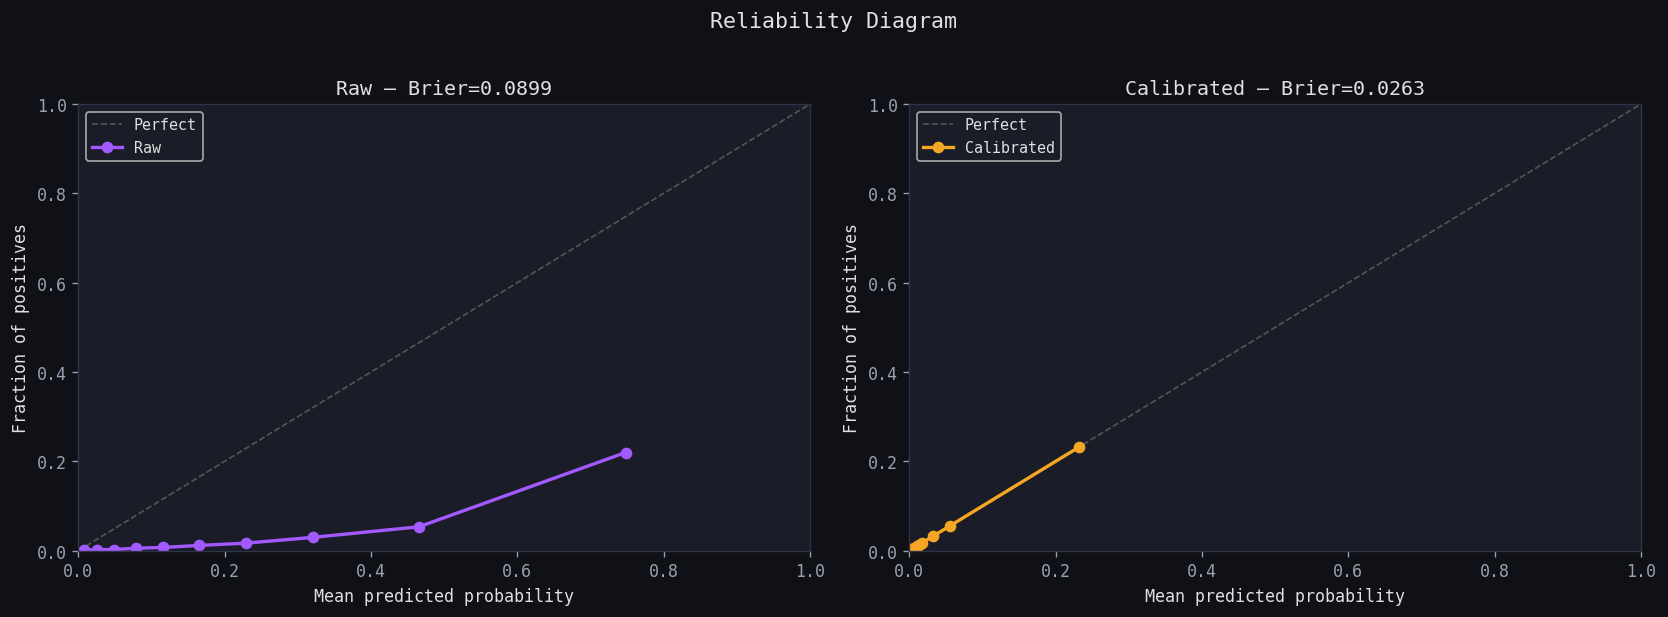

In [5]:
iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(raw_scores, y_test)
cal_scores = iso.predict(raw_scores).astype(np.float64)

brier_raw = brier_score_loss(y_test, raw_scores)
brier_cal = brier_score_loss(y_test, cal_scores)
print(f"Brier score — raw: {brier_raw:.4f}  calibrated: {brier_cal:.4f}  (lower is better)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#0F1117")
for ax, sc, lbl, col in [(axes[0],raw_scores,"Raw",PAL["lgb"]),(axes[1],cal_scores,"Calibrated",PAL["accent"])]:
    fp, mp = calibration_curve(y_test, sc, n_bins=10, strategy="quantile")
    ax.plot([0,1],[0,1],"--",color="#555",lw=1,label="Perfect")
    ax.plot(mp, fp, "o-", color=col, lw=2, markersize=6, label=lbl)
    ax.set_title(f"{lbl} — Brier={brier_score_loss(y_test,sc):.4f}", color="#E0E0E0")
    ax.set_xlabel("Mean predicted probability"); ax.set_ylabel("Fraction of positives")
    ax.legend(fontsize=9); ax.set_xlim(0,1); ax.set_ylim(0,1)
plt.suptitle("Reliability Diagram", fontsize=13, color="#E0E0E0", y=1.02)
plt.tight_layout(); plt.show()


## 3 · ROC, PR, score distribution & cost curves

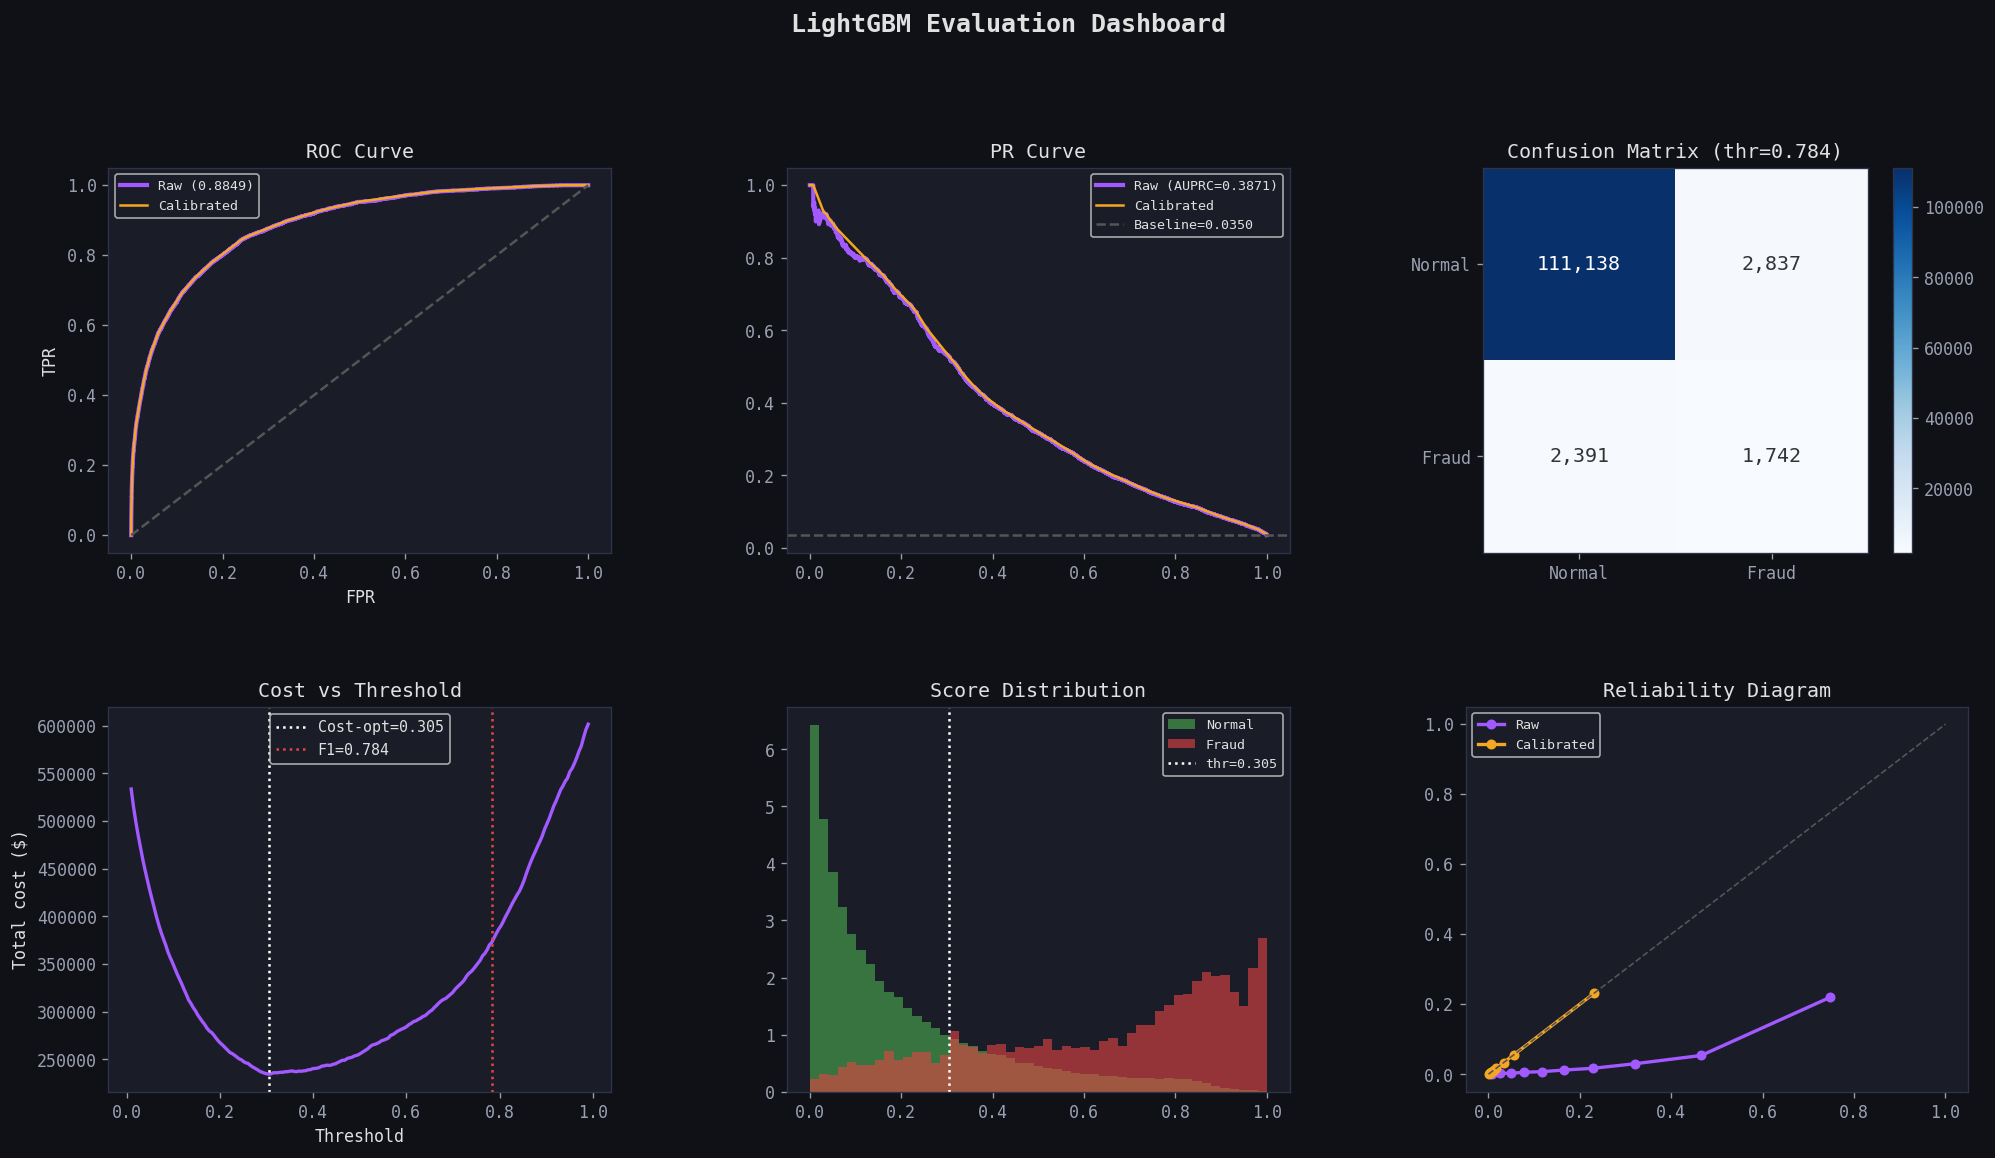

In [6]:
fig = plt.figure(figsize=(20, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)
fig.patch.set_facecolor("#0F1117")

ax1 = fig.add_subplot(gs[0,0])
for sc,lb,col,lw in [(raw_scores,f"Raw ({auroc:.4f})",PAL["lgb"],2.5),(cal_scores,"Calibrated",PAL["accent"],1.5)]:
    fpr_,tpr_,_ = roc_curve(y_test,sc); ax1.plot(fpr_,tpr_,color=col,lw=lw,label=lb)
ax1.plot([0,1],[0,1],"--",color="#555"); ax1.set_title("ROC Curve",color="#E0E0E0")
ax1.set_xlabel("FPR"); ax1.set_ylabel("TPR"); ax1.legend(fontsize=8)

ax2 = fig.add_subplot(gs[0,1])
for sc,lb,col,lw in [(raw_scores,f"Raw (AUPRC={auprc:.4f})",PAL["lgb"],2.5),(cal_scores,"Calibrated",PAL["accent"],1.5)]:
    p_,r_,_ = precision_recall_curve(y_test,sc); ax2.plot(r_,p_,color=col,lw=lw,label=lb)
ax2.axhline(y_test.mean(),color="#555",ls="--",label=f"Baseline={y_test.mean():.4f}")
ax2.set_title("PR Curve",color="#E0E0E0"); ax2.legend(fontsize=8)

ax3 = fig.add_subplot(gs[0,2])
im = ax3.imshow(cm, cmap="Blues")
ax3.set_xticks([0,1]); ax3.set_yticks([0,1])
ax3.set_xticklabels(["Normal","Fraud"]); ax3.set_yticklabels(["Normal","Fraud"])
ax3.set_title(f"Confusion Matrix (thr={thr_f1:.3f})",color="#E0E0E0")
for i in range(2):
    for j in range(2):
        ax3.text(j,i,f"{cm[i,j]:,}",ha="center",va="center",fontsize=12,
                 color="white" if cm[i,j]>cm.max()/2 else "#333")
plt.colorbar(im,ax=ax3)

ax4 = fig.add_subplot(gs[1,0])
ax4.plot(thr_range,costs,color=PAL["lgb"],lw=2)
ax4.axvline(thr_cost,color="white",lw=1.5,ls=":",label=f"Cost-opt={thr_cost:.3f}")
ax4.axvline(thr_f1,color=PAL["fraud"],lw=1.5,ls=":",label=f"F1={thr_f1:.3f}")
ax4.set_title("Cost vs Threshold",color="#E0E0E0")
ax4.set_xlabel("Threshold"); ax4.set_ylabel("Total cost ($)"); ax4.legend(fontsize=9)

ax5 = fig.add_subplot(gs[1,1])
bins = np.linspace(0,1,50)
ax5.hist(raw_scores[y_test==0],bins=bins,alpha=0.6,color=PAL["normal"],label="Normal",density=True)
ax5.hist(raw_scores[y_test==1],bins=bins,alpha=0.6,color=PAL["fraud"],label="Fraud",density=True)
ax5.axvline(thr_cost,color="white",lw=1.5,ls=":",label=f"thr={thr_cost:.3f}")
ax5.set_title("Score Distribution",color="#E0E0E0"); ax5.legend(fontsize=8)

ax6 = fig.add_subplot(gs[1,2])
for sc,lb,col in [(raw_scores,"Raw",PAL["lgb"]),(cal_scores,"Calibrated",PAL["accent"])]:
    fp,mp = calibration_curve(y_test,sc,n_bins=10,strategy="quantile")
    ax6.plot(mp,fp,"o-",color=col,lw=2,markersize=5,label=lb)
ax6.plot([0,1],[0,1],"--",color="#555",lw=1)
ax6.set_title("Reliability Diagram",color="#E0E0E0"); ax6.legend(fontsize=8)

fig.suptitle("LightGBM Evaluation Dashboard",fontsize=15,fontweight="bold",color="#E0E0E0",y=1.01)
plt.show()


## 4 · Precision@K and lift curve

Precision@K (top-scored transactions):
     K  Precision     Lift
----------------------------
    10     1.0000    28.58x
    25     1.0000    28.58x
    50     0.9200    26.29x
   100     0.9000    25.72x
   200     0.9000    25.72x
   500     0.8060    23.03x


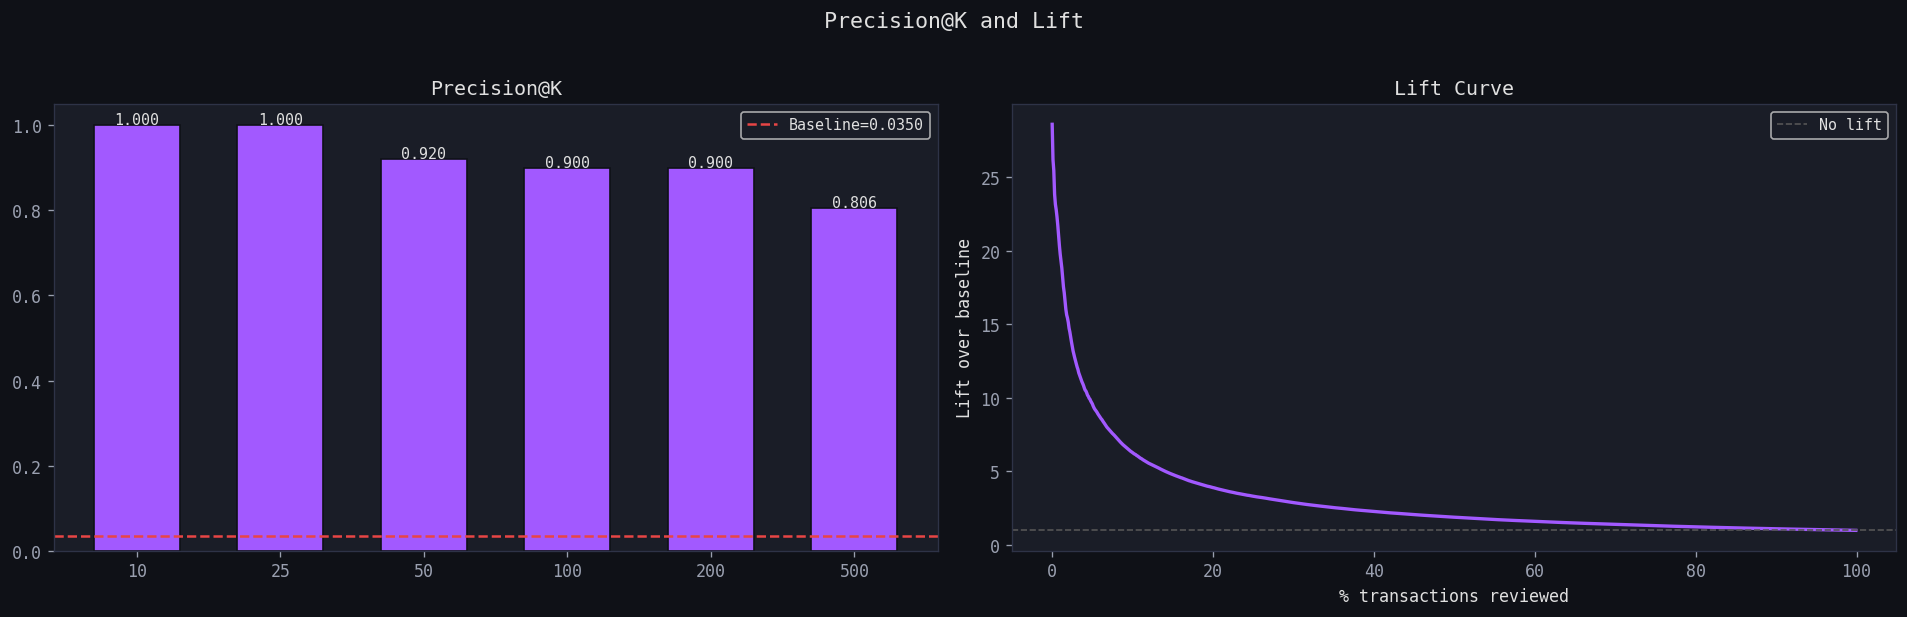

In [7]:
KS = [10, 25, 50, 100, 200, 500]
sorted_idx = np.argsort(raw_scores)[::-1]
baseline   = float(y_test.mean())

pk_vals = {k: round(float(y_test[sorted_idx[:k]].sum()/k),4) for k in KS}
print("Precision@K (top-scored transactions):")
print(f"{'K':>6} {'Precision':>10} {'Lift':>8}")
print("-"*28)
for k,v in pk_vals.items():
    print(f"{k:>6} {v:>10.4f} {v/baseline:>8.2f}x")

cumulative = np.cumsum(y_test[sorted_idx])
k_range    = np.arange(1, len(y_test)+1)
prec_k     = cumulative/k_range; lift_k = prec_k/(baseline+1e-9)

fig, axes = plt.subplots(1,2,figsize=(16,5))
fig.patch.set_facecolor("#0F1117")

bars = axes[0].bar([str(k) for k in KS],[pk_vals[k] for k in KS],
                   color=PAL["lgb"],edgecolor="#0F1117",width=0.6)
axes[0].axhline(baseline,color=PAL["fraud"],ls="--",lw=1.5,label=f"Baseline={baseline:.4f}")
for bar,val in zip(bars,[pk_vals[k] for k in KS]):
    axes[0].text(bar.get_x()+bar.get_width()/2,val+0.003,f"{val:.3f}",
                 ha="center",fontsize=9,color="#E0E0E0")
axes[0].set_title("Precision@K",color="#E0E0E0"); axes[0].legend(fontsize=9)

step = max(1,len(y_test)//1000)
axes[1].plot(k_range[::step]/len(y_test)*100,lift_k[::step],color=PAL["lgb"],lw=2)
axes[1].axhline(1.0,color="#555",ls="--",lw=1,label="No lift")
axes[1].set_title("Lift Curve",color="#E0E0E0")
axes[1].set_xlabel("% transactions reviewed"); axes[1].set_ylabel("Lift over baseline")
axes[1].legend(fontsize=9)
plt.suptitle("Precision@K and Lift",fontsize=13,color="#E0E0E0",y=1.02); plt.tight_layout(); plt.show()


## 5 · Time-period analysis (weekly)

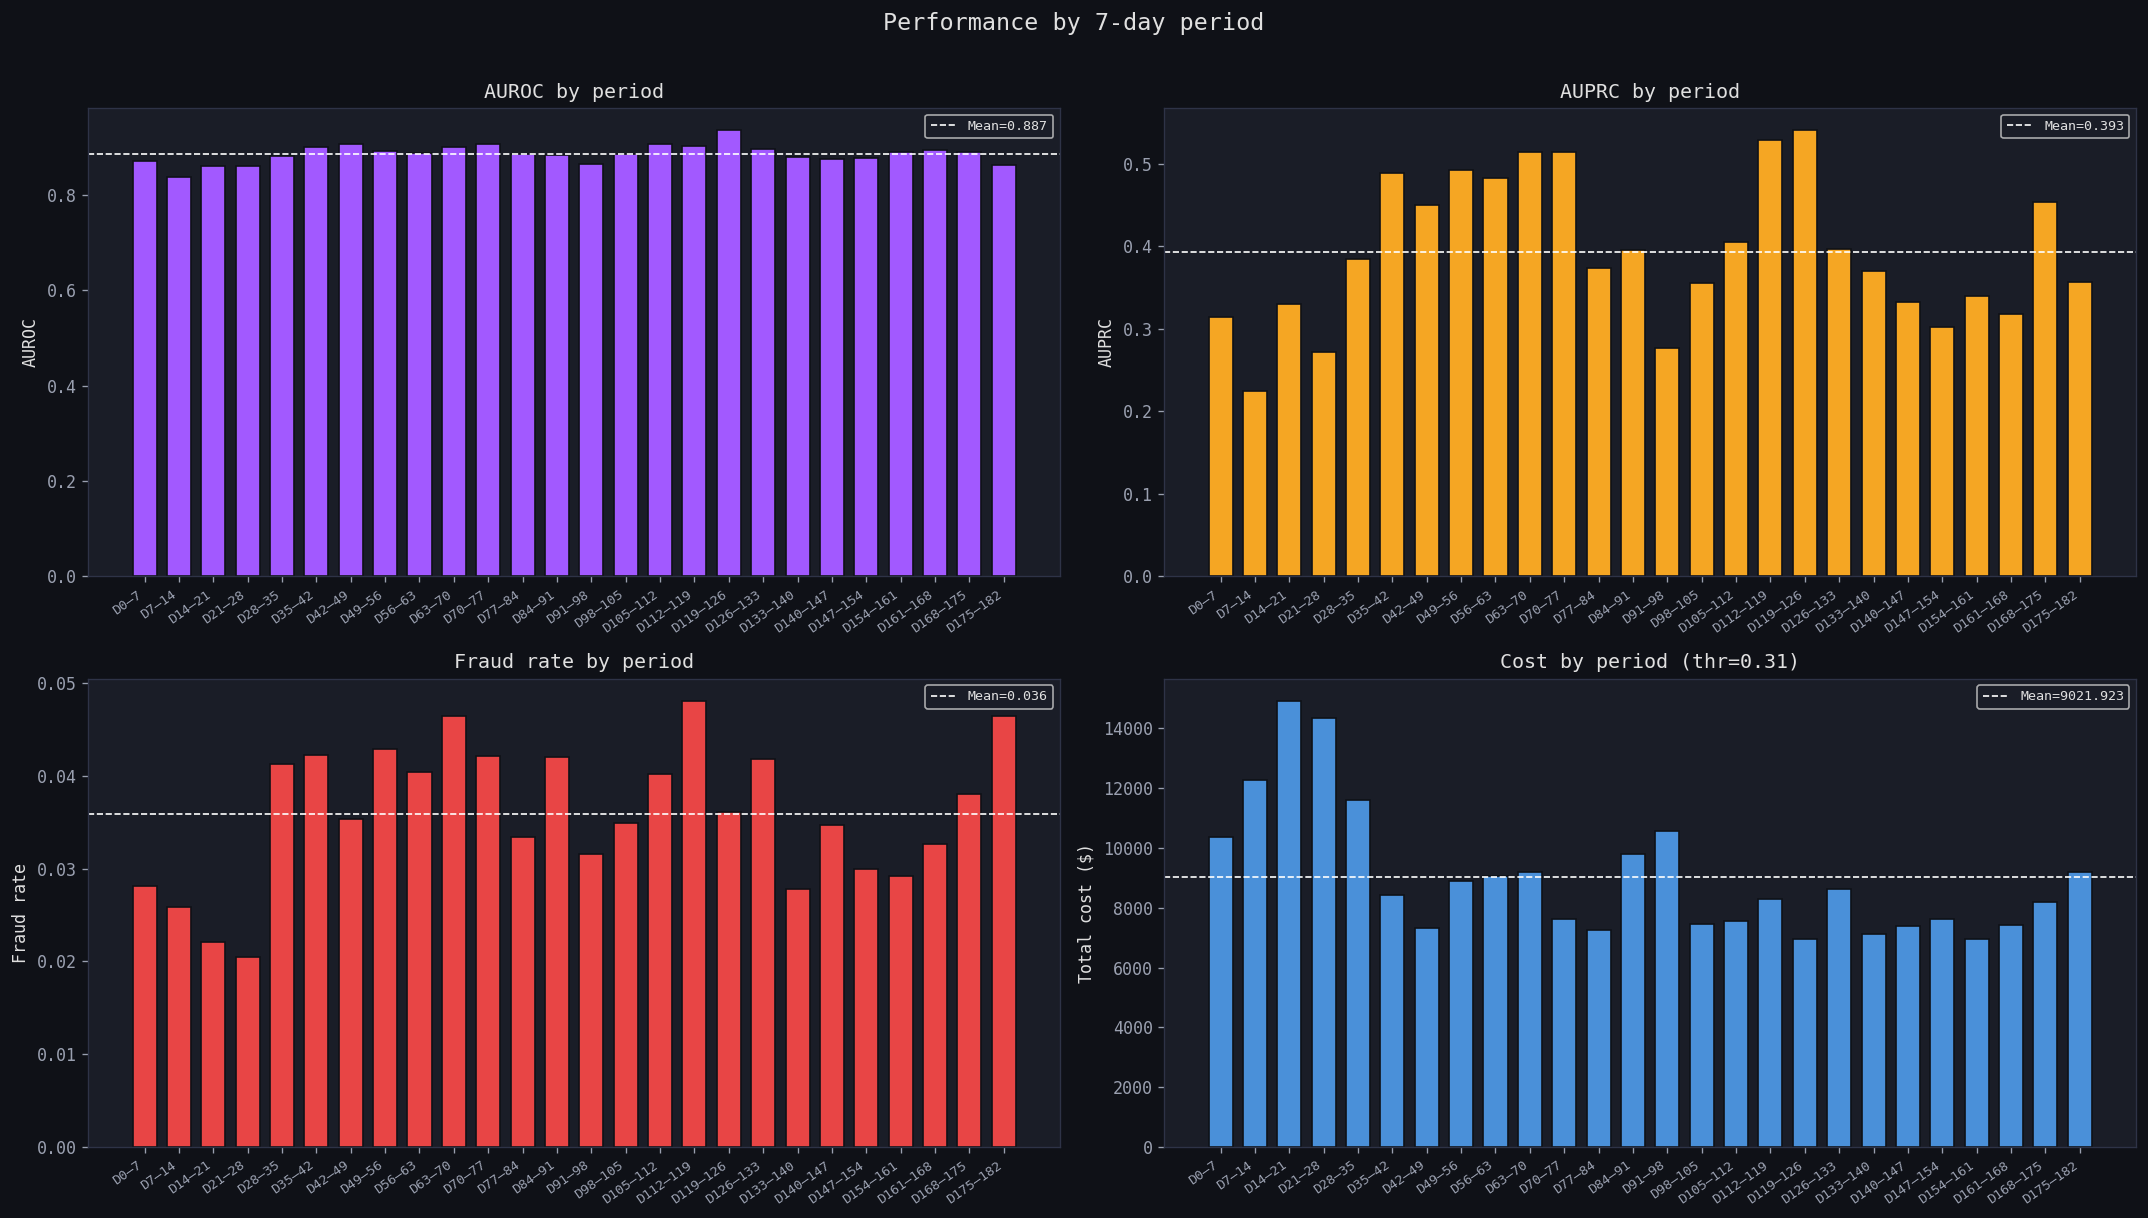


Periods analysed   : 26
AUROC first period : 0.8717
AUROC last  period : 0.8637
AUROC period std   : 0.0192
✓  AUROC stable across periods


In [8]:
PERIOD_DAYS = 7
dt_days   = (tx_dt_test - tx_dt_test.min()) / 86_400
n_periods = max(1, int(np.ceil(dt_days.max()/PERIOD_DAYS)))

period_stats = []
for p in range(n_periods):
    mask = (dt_days >= p*PERIOD_DAYS) & (dt_days < (p+1)*PERIOD_DAYS)
    if mask.sum() < 50 or y_test[mask].sum() < 2: continue
    y_p = y_test[mask]; s_p = raw_scores[mask]
    yp  = (s_p >= thr_cost).astype(int)
    tn_,fp_,fn_,tp_ = confusion_matrix(y_p, yp, labels=[0,1]).ravel()
    period_stats.append({
        "period": p+1, "label": f"D{p*PERIOD_DAYS}–{(p+1)*PERIOD_DAYS}",
        "n_tx": mask.sum(), "fraud_rate": float(y_p.mean()),
        "auroc": float(roc_auc_score(y_p, s_p)),
        "auprc": float(average_precision_score(y_p, s_p)),
        "cost": float(fn_*COST_FN + fp_*COST_FP),
    })

labels  = [s["label"]      for s in period_stats]
aurocs  = [s["auroc"]      for s in period_stats]
auprcs  = [s["auprc"]      for s in period_stats]
frates  = [s["fraud_rate"] for s in period_stats]
pcosts  = [s["cost"]       for s in period_stats]

fig, axes = plt.subplots(2,2,figsize=(18,10))
fig.patch.set_facecolor("#0F1117")

def _bar(ax, vals, title, ylabel, col):
    xs = range(len(vals))
    ax.bar(xs, vals, color=col, edgecolor="#0F1117", width=0.7)
    ax.set_xticks(list(xs)); ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=8)
    ax.set_title(title, color="#E0E0E0"); ax.set_ylabel(ylabel)
    ax.axhline(float(np.nanmean(vals)), color="white", ls="--", lw=1,
               label=f"Mean={np.nanmean(vals):.3f}"); ax.legend(fontsize=8)

_bar(axes[0,0], aurocs, "AUROC by period",           "AUROC",          PAL["lgb"])
_bar(axes[0,1], auprcs, "AUPRC by period",           "AUPRC",          PAL["accent"])
_bar(axes[1,0], frates, "Fraud rate by period",      "Fraud rate",     PAL["fraud"])
_bar(axes[1,1], pcosts, f"Cost by period (thr={thr_cost:.2f})", "Total cost ($)", PAL["blue"])

plt.suptitle(f"Performance by {PERIOD_DAYS}-day period",fontsize=14,color="#E0E0E0",y=1.01)
plt.tight_layout(); plt.show()

print(f"\nPeriods analysed   : {len(period_stats)}")
print(f"AUROC first period : {aurocs[0]:.4f}")
print(f"AUROC last  period : {aurocs[-1]:.4f}")
print(f"AUROC period std   : {np.std(aurocs):.4f}")
if aurocs[-1] < aurocs[0] - 0.05:
    print("⚠  AUROC dropped >5pp from first to last period — monitor for drift")
else:
    print("✓  AUROC stable across periods")


## 6 · SHAP interpretability

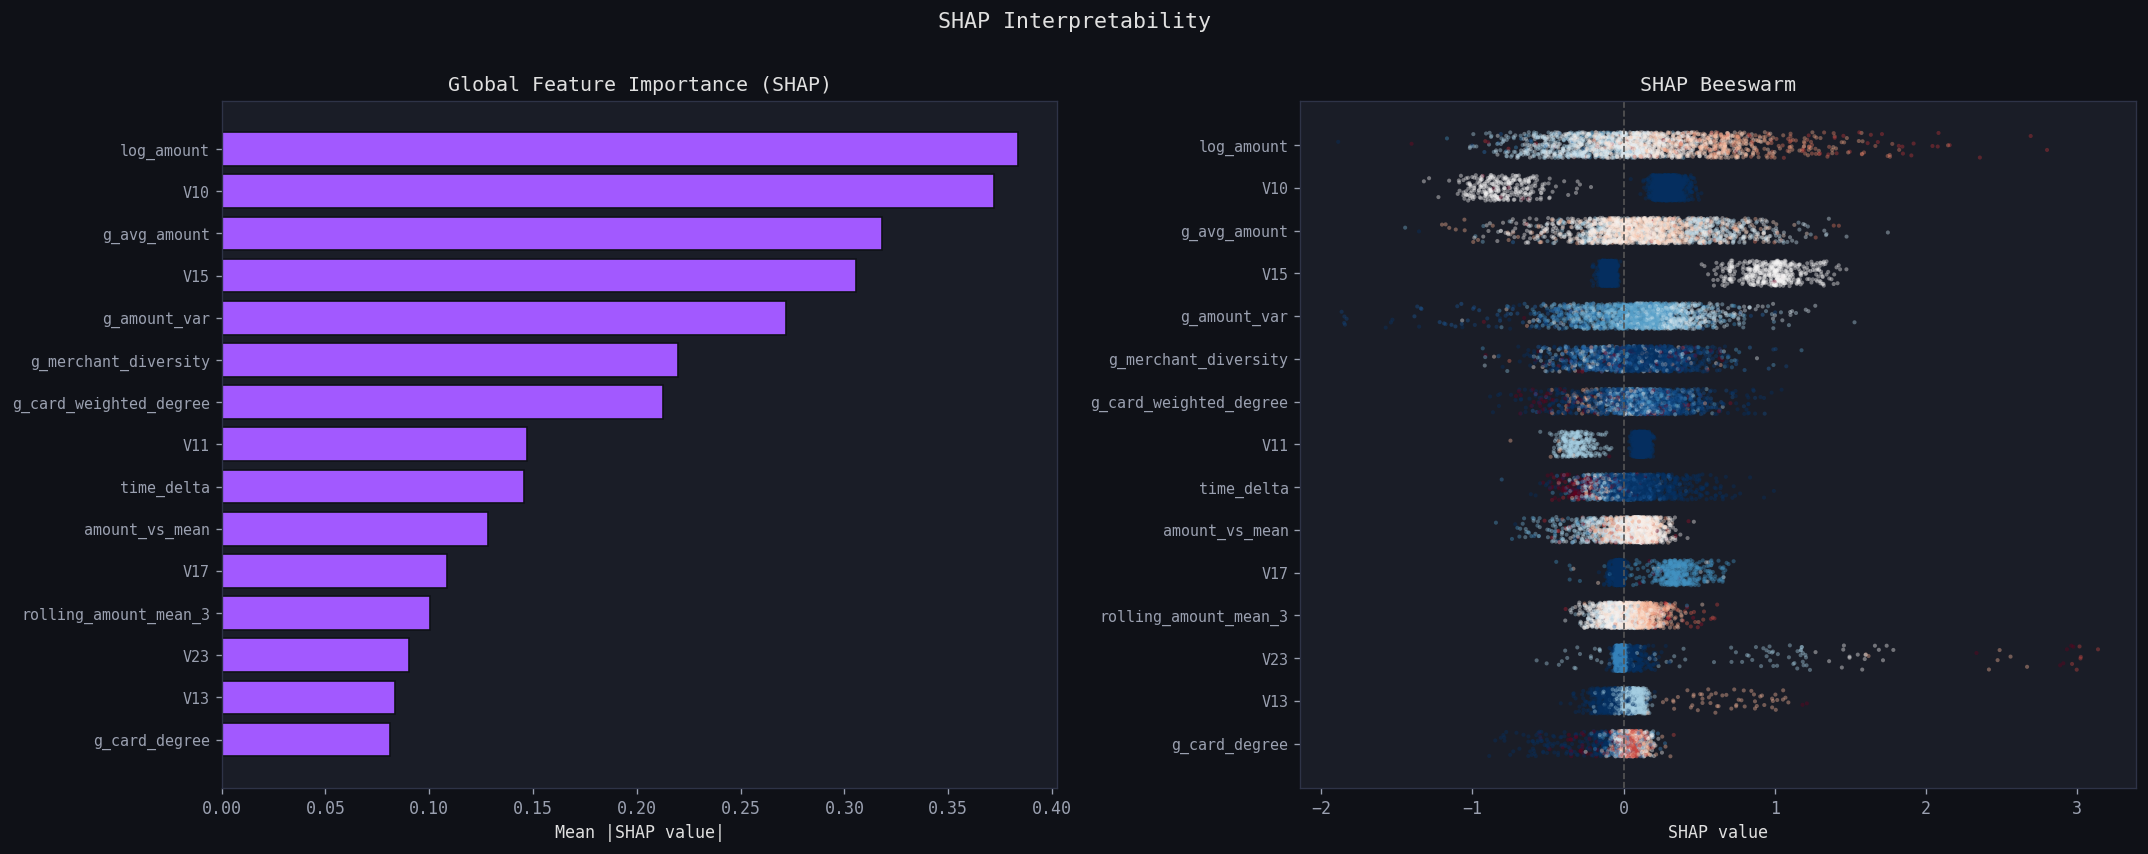

In [9]:
mean_abs = np.abs(shap_values).mean(0)
order    = np.argsort(mean_abs)[::-1]
top15_idx   = order[:15]
top15_names = [shap_names[i] for i in top15_idx]

fig, axes = plt.subplots(1,2,figsize=(18,7))
fig.patch.set_facecolor("#0F1117")

axes[0].barh(range(15),mean_abs[top15_idx][::-1],color=PAL["lgb"],edgecolor="#0F1117")
axes[0].set_yticks(range(15)); axes[0].set_yticklabels(top15_names[::-1],fontsize=9)
axes[0].set_xlabel("Mean |SHAP value|")
axes[0].set_title("Global Feature Importance (SHAP)",color="#E0E0E0",fontsize=12)

shap_15  = shap_values[:,top15_idx]
shap_fts = X_test[shap_idx][:,top15_idx]
ft_min   = shap_fts.min(0); ft_max = shap_fts.max(0)
ft_norm  = (shap_fts-ft_min)/(ft_max-ft_min+1e-9)
rng = np.random.default_rng(0)
for rank in range(14,-1,-1):
    yp = np.full(len(shap_15), 14-rank); jitter=rng.uniform(-0.3,0.3,len(shap_15))
    colors=plt.cm.RdBu_r(ft_norm[:,rank])
    axes[1].scatter(shap_15[:,rank],yp+jitter,c=colors,alpha=0.4,s=6,linewidths=0)
axes[1].set_yticks(range(15)); axes[1].set_yticklabels(top15_names[::-1],fontsize=9)
axes[1].axvline(0,color="#555",lw=1,ls="--")
axes[1].set_xlabel("SHAP value"); axes[1].set_title("SHAP Beeswarm",color="#E0E0E0",fontsize=12)
plt.suptitle("SHAP Interpretability",fontsize=13,color="#E0E0E0",y=1.01)
plt.tight_layout(); plt.show()


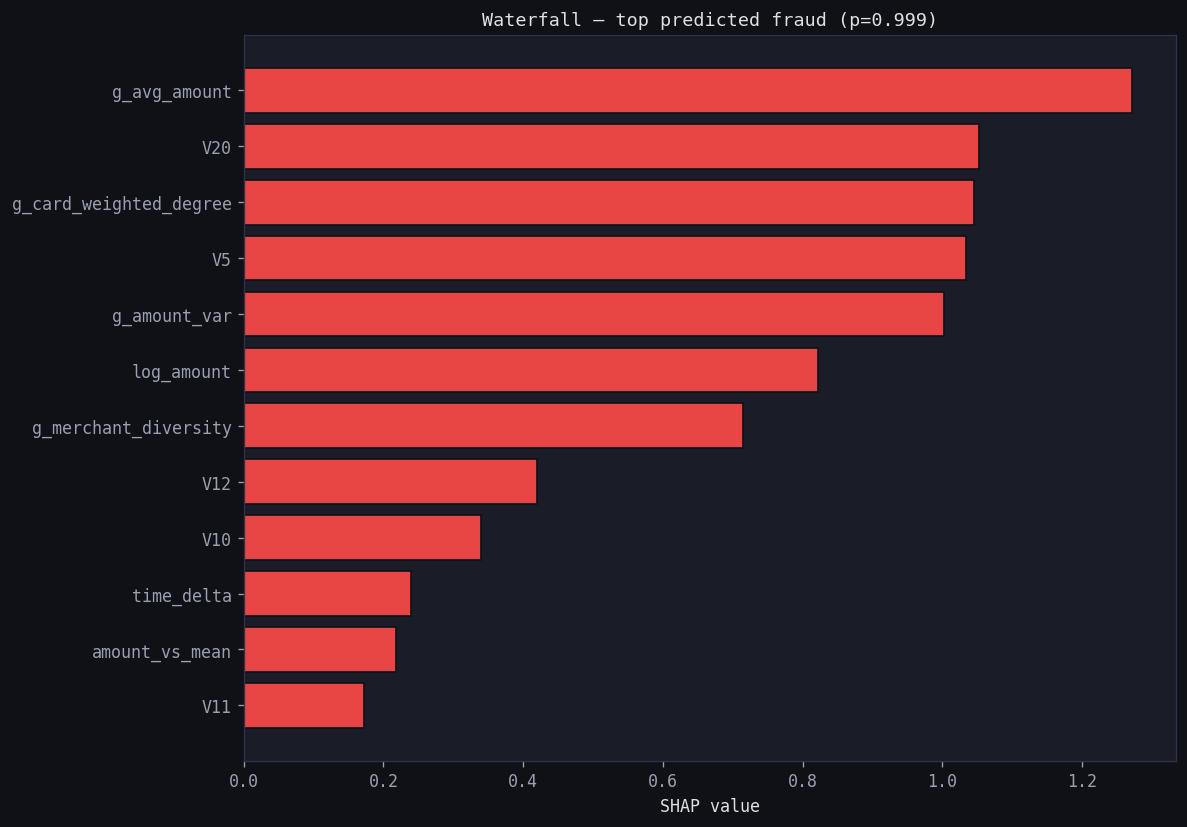

In [10]:
# Waterfall — highest-confidence fraud transaction
fraud_in_sample = np.where(y_test[shap_idx]==1)[0]
if len(fraud_in_sample) > 0:
    top_f  = fraud_in_sample[np.argmax(shap_values[fraud_in_sample].sum(1))]
    sv     = shap_values[top_f]
    wf_ord = np.argsort(np.abs(sv))[::-1][:12]
    names_ = [shap_names[i] for i in wf_ord]; vals_ = sv[wf_ord]
    cols_  = [PAL["fraud"] if v>0 else PAL["normal"] for v in vals_]

    fig, ax = plt.subplots(figsize=(10,7)); fig.patch.set_facecolor("#0F1117"); ax.set_facecolor("#1A1D27")
    ax.barh(range(len(vals_)),vals_[::-1],color=cols_[::-1],edgecolor="#0F1117")
    ax.set_yticks(range(len(vals_))); ax.set_yticklabels(names_[::-1],fontsize=10)
    ax.axvline(0,color="#555",lw=1,ls="--"); ax.set_xlabel("SHAP value")
    ax.set_title(f"Waterfall — top predicted fraud (p={raw_scores[shap_idx[top_f]]:.3f})",
                 color="#E0E0E0",fontsize=11)
    ax.tick_params(colors="#9AA0B0"); plt.tight_layout(); plt.show()
